In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix
)

df = pd.read_csv("housing.csv")

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

df["total_bedrooms"] = df["total_bedrooms"].fillna(
    df["total_bedrooms"].median()
)

Shape: (20640, 10)

Columns:
Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

Data Types:
longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity        object
dtype: object

Missing Values:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


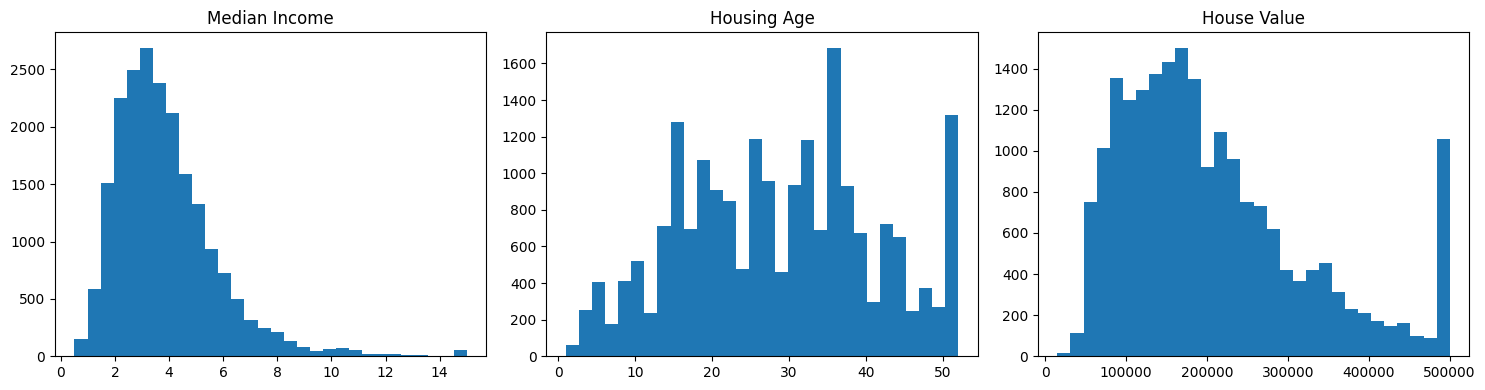

In [18]:
fig, axes = plt.subplots(1,3,figsize=(15,4))

axes[0].hist(df["median_income"], bins=30)
axes[0].set_title("Median Income")

axes[1].hist(df["housing_median_age"], bins=30)
axes[1].set_title("Housing Age")

axes[2].hist(df["median_house_value"], bins=30)
axes[2].set_title("House Value")

plt.tight_layout()
plt.show()

In [19]:
df["expensive"] = (
    df["median_house_value"] >
    df["median_house_value"].median()
).astype(int)

X = df[[
    "median_income",
    "housing_median_age",
    "total_rooms",
    "population"
]]

y = df["expensive"]

X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)

model = LogisticRegression(max_iter=5000)

model.fit(X_train,y_train)

pred = model.predict(X_test)

print("Accuracy:",accuracy_score(y_test,pred))
print("Precision:",precision_score(y_test,pred))
print("Recall:",recall_score(y_test,pred))

Accuracy: 0.7671996124031008
Precision: 0.7856394129979035
Recall: 0.7308629936616284


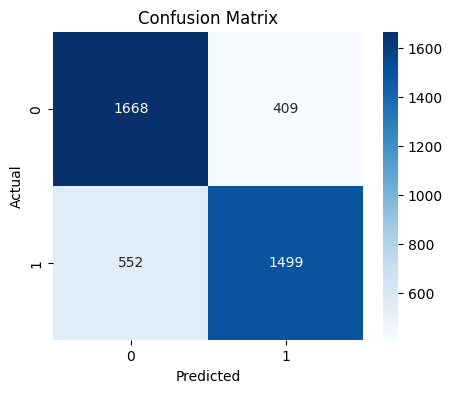


Target Variable:
median_house_value

Features:
longitude, latitude, housing_median_age,
total_rooms, total_bedrooms, population,
households, median_income, ocean_proximity

Reasoning:
median_income, location and ocean proximity
appear most useful for predicting house value.

Accuracy alone is not enough because a model
may have high accuracy while missing important
positive cases. Precision and Recall provide
additional information about model quality.



In [20]:
cm = confusion_matrix(y_test,pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("""
Target Variable:
median_house_value

Features:
longitude, latitude, housing_median_age,
total_rooms, total_bedrooms, population,
households, median_income, ocean_proximity

Reasoning:
median_income, location and ocean proximity
appear most useful for predicting house value.

Accuracy alone is not enough because a model
may have high accuracy while missing important
positive cases. Precision and Recall provide
additional information about model quality.
""")